In [1]:
pip install tensorflow pillow matplotlib numpy --break-system-packages

In [23]:
import os
import ssl
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Fix SSL certificate errors when downloading pretrained weights
ssl._create_default_https_context = ssl._create_unverified_context

# Reduce noisy TensorFlow log output
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input as mobilenet_preprocess,
    decode_predictions as mobilenet_decode,
)
from tensorflow.keras.applications.resnet50 import (
    preprocess_input as resnet_preprocess,
    decode_predictions as resnet_decode,
)
from tensorflow.keras.applications.efficientnet import (
    preprocess_input as efficientnet_preprocess,
    decode_predictions as efficientnet_decode,
)

MODEL_REGISTRY = {
    "mobilenet": {
        "builder": MobileNetV2, "input_size": (224, 224),
        "preprocess": mobilenet_preprocess, "decode": mobilenet_decode,
        "display_name": "MobileNetV2",
    },
    "resnet50": {
        "builder": ResNet50, "input_size": (224, 224),
        "preprocess": resnet_preprocess, "decode": resnet_decode,
        "display_name": "ResNet50",
    },
    "efficientnet": {
        "builder": EfficientNetB0, "input_size": (224, 224),
        "preprocess": efficientnet_preprocess, "decode": efficientnet_decode,
        "display_name": "EfficientNetB0",
    },
}

_MODEL_CACHE = {}


def upload_image():
    from google.colab import files
    uploaded = files.upload()
    if not uploaded:
        raise RuntimeError("No file was uploaded.")
    image_path = list(uploaded.keys())[0]
    print(f"[INFO] Uploaded file saved as: {image_path}")
    return image_path


def load_model(model_key):
    if model_key not in MODEL_REGISTRY:
        raise ValueError(f"Unknown model '{model_key}'. Choose from: {list(MODEL_REGISTRY.keys())}")
    if model_key in _MODEL_CACHE:
        return _MODEL_CACHE[model_key]
    config = MODEL_REGISTRY[model_key]
    print(f"[INFO] Loading {config['display_name']} (pretrained on ImageNet)...")
    model = config["builder"](weights="imagenet")
    print("[INFO] Model loaded successfully.\n")
    _MODEL_CACHE[model_key] = (model, config)
    return model, config


def load_and_prepare_image(image_path, target_size):
    if not os.path.exists(image_path):
        raise FileNotFoundError(
            f"Image not found: '{image_path}'.\n"
            f"Run `IMAGE_PATH = upload_image()` to upload a file from your computer."
        )
    try:
        original = Image.open(image_path).convert("RGB")
    except Exception:
        raise ValueError(f"'{image_path}' exists but is not a valid image file.")

    resized = original.resize(target_size)
    img_array = np.array(resized).astype(np.float32)
    img_array = np.expand_dims(img_array, axis=0)
    return original, img_array


def get_image_metadata(image_path, original_image):
    file_size_kb = os.path.getsize(image_path) / 1024
    return {
        "File name": os.path.basename(image_path),
        "File size": f"{file_size_kb:.1f} KB",
        "Dimensions": f"{original_image.width} x {original_image.height} px",
        "Mode": original_image.mode,
        "Format (on disk)": os.path.splitext(image_path)[1].upper().lstrip("."),
    }


def predict(model, config, img_array, top_k=5):
    processed = config["preprocess"](img_array.copy())
    preds = model.predict(processed, verbose=0)
    return config["decode"](preds, top=top_k)[0]


def print_report(metadata, model_name, predictions):
    print("=" * 50)
    print("IMAGE ANALYSIS REPORT")
    print("=" * 50)
    print("\n--- Image Details ---")
    for key, value in metadata.items():
        print(f"{key:<18}: {value}")
    print(f"\n--- Model Used ---\n{model_name}")
    print("\n--- Top Predictions ---")
    for i, (_, label, score) in enumerate(predictions, start=1):
        readable_label = label.replace("_", " ").title()
        print(f"{i}. {readable_label:<25} confidence: {score * 100:.2f}%")
    print("=" * 50)


def visualize(original_image, metadata, model_name, predictions):
    fig, (ax_img, ax_text) = plt.subplots(1, 2, figsize=(11, 5.5))

    ax_img.imshow(original_image)
    ax_img.axis("off")
    ax_img.set_title("Input Image", fontsize=13, fontweight="bold")

    ax_text.axis("off")
    lines = ["IMAGE DETAILS", "-" * 28]
    for key, value in metadata.items():
        lines.append(f"{key}: {value}")
    lines += ["", f"MODEL: {model_name}", "-" * 28, "TOP PREDICTIONS"]
    for i, (_, label, score) in enumerate(predictions, start=1):
        readable_label = label.replace("_", " ").title()
        lines.append(f"{i}. {readable_label} - {score * 100:.2f}%")

    ax_text.text(0, 1, "\n".join(lines), fontsize=11, va="top", ha="left",
                  family="monospace", transform=ax_text.transAxes)

    top_labels = [p[1].replace("_", " ").title() for p in predictions][::-1]
    top_scores = [p[2] * 100 for p in predictions][::-1]

    bar_ax = fig.add_axes([0.55, 0.08, 0.4, 0.28])
    bar_ax.barh(top_labels, top_scores, color="#4C72B0")
    bar_ax.set_xlim(0, 100)
    bar_ax.set_xlabel("Confidence (%)")
    bar_ax.set_title("Prediction Confidence", fontsize=10)
    for spine in ["top", "right"]:
        bar_ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()


def analyze(image_path, model_name="mobilenet", top_k=5):
    model, config = load_model(model_name)
    original_image, img_array = load_and_prepare_image(image_path, config["input_size"])
    metadata = get_image_metadata(image_path, original_image)
    predictions = predict(model, config, img_array, top_k=top_k)
    print_report(metadata, config["display_name"], predictions)
    visualize(original_image, metadata, config["display_name"], predictions)
    return predictions

print("[INFO] Setup complete. Run the next cell to upload and analyze an image.")

[INFO] Setup complete. Run the next cell to upload and analyze an image.


In [27]:
IMAGE_PATH = upload_image()

Saving Dog.jfif to Dog.jfif
[INFO] Uploaded file saved as: Dog.jfif


IMAGE ANALYSIS REPORT

--- Image Details ---
File name         : Dog.jfif
File size         : 5.7 KB
Dimensions        : 225 x 224 px
Mode              : RGB
Format (on disk)  : JFIF

--- Model Used ---
MobileNetV2

--- Top Predictions ---
1. Golden Retriever          confidence: 37.40%
2. Standard Poodle           confidence: 16.69%
3. Miniature Poodle          confidence: 4.15%
4. Afghan Hound              confidence: 3.98%
5. Bedlington Terrier        confidence: 3.83%


/tmp/ipykernel_23974/1341953644.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


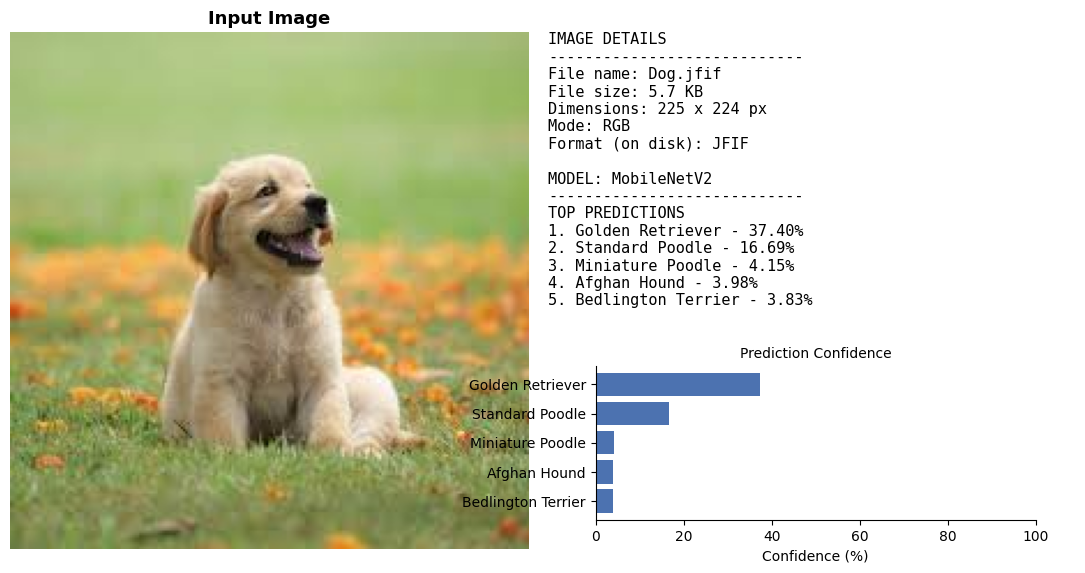

[('n02099601', 'golden_retriever', np.float32(0.37399688)),
 ('n02113799', 'standard_poodle', np.float32(0.16693786)),
 ('n02113712', 'miniature_poodle', np.float32(0.041513022)),
 ('n02088094', 'Afghan_hound', np.float32(0.039760422)),
 ('n02093647', 'Bedlington_terrier', np.float32(0.038267538))]

In [28]:
analyze(IMAGE_PATH, model_name="mobilenet", top_k=5)